In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_pre_path = "../train/pre-event"
train_post_path = "../train/post-event"
train_target_path = "../train/target"

In [3]:
files = os.listdir(train_pre_path)

print("Total training samples:", len(files))
print(files[:5])

Total training samples: 2781
['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif', 'scene_01_000004_building_damage.tif', 'scene_01_000005_building_damage.tif']


In [4]:
def load_sample(filename):
    
    pre_image = cv2.imread(os.path.join(train_pre_path, filename))
    
    post_image = cv2.imread(os.path.join(train_post_path, filename))
    
    target_image = cv2.imread(
        os.path.join(train_target_path, filename),
        cv2.IMREAD_GRAYSCALE
    )

    return pre_image, post_image, target_image

In [5]:
pre, post, target = load_sample(files[0])

print("Pre-event shape:", pre.shape)
print("Post-event shape:", post.shape)
print("Target shape:", target.shape)


Pre-event shape: (1024, 1024, 3)
Post-event shape: (1024, 1024, 3)
Target shape: (1024, 1024)


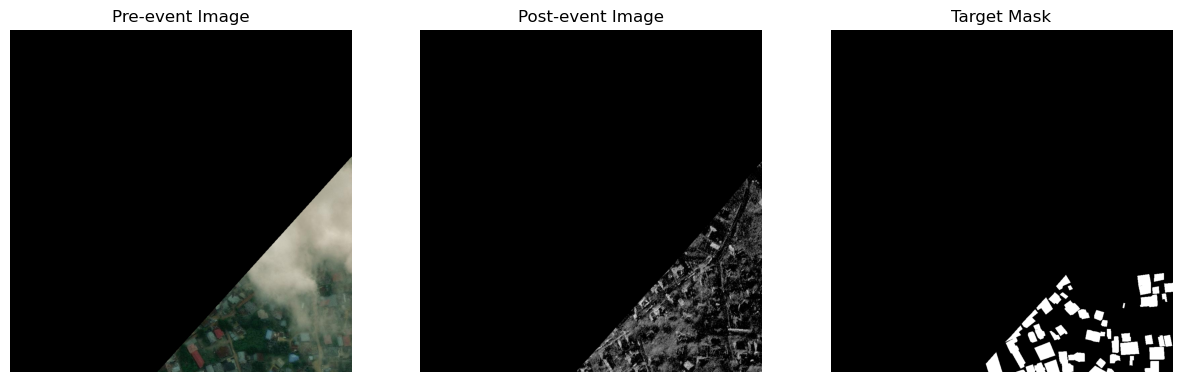

In [6]:
plt.figure(figsize=(15,5))

# Pre-event image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(pre, cv2.COLOR_BGR2RGB))
plt.title("Pre-event Image")
plt.axis("off")

# Post-event image
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(post, cv2.COLOR_BGR2RGB))
plt.title("Post-event Image")
plt.axis("off")

# Target mask
plt.subplot(1,3,3)
plt.imshow(target, cmap='gray')
plt.title("Target Mask")
plt.axis("off")

plt.show()

In [7]:
#RESIZING THE IMAGES BECAUSE THAT AI TRAINS IT BETTER WITH SMALLER DIMENSIONS
IMG_SIZE = 256

def preprocess_sample(pre, post, target):

    # Resize images
    pre = cv2.resize(pre, (IMG_SIZE, IMG_SIZE))
    post = cv2.resize(post, (IMG_SIZE, IMG_SIZE))
    target = cv2.resize(target, (IMG_SIZE, IMG_SIZE))

    # Normalize images
    pre = pre / 255.0
    post = post / 255.0
    target = target / 255.0

    # Combine pre and post images
    combined = np.concatenate([pre, post], axis=-1)

    return combined, target

In [8]:
combined, processed_target = preprocess_sample(pre, post, target)

print("Combined shape:", combined.shape)
print("Processed target shape:", processed_target.shape)

Combined shape: (256, 256, 6)
Processed target shape: (256, 256)


In [9]:
X_train = []
y_train = []

In [10]:
for filename in files:

    # Load images
    pre, post, target = load_sample(filename)

    # Preprocess images
    combined, processed_target = preprocess_sample(pre, post, target)

    # Store in lists
    X_train.append(combined)
    y_train.append(processed_target)

In [14]:
X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2781, 256, 256, 6)
y_train shape: (2781, 256, 256)


In [15]:
#SAME ABOVE STEPS OF PREPROCESSING BUT FOR VAL FOLDER
val_pre_path = "../val/pre-event"
val_post_path = "../val/post-event"
val_target_path = "../val/target"

In [16]:
def load_val_sample(filename):

    pre = cv2.imread(os.path.join(val_pre_path, filename))
    
    post = cv2.imread(os.path.join(val_post_path, filename))
    
    target = cv2.imread(
        os.path.join(val_target_path, filename),
        cv2.IMREAD_GRAYSCALE
    )

    return pre, post, target

In [17]:
val_files = os.listdir(val_pre_path)

print("Validation samples:", len(val_files))
print(val_files[:5])

Validation samples: 334
['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif', 'scene_01_000004_building_damage.tif', 'scene_01_000005_building_damage.tif']


In [18]:
X_val = []
y_val = []

for filename in val_files:

    pre, post, target = load_val_sample(filename)

    combined, processed_target = preprocess_sample(pre, post, target)

    X_val.append(combined)
    y_val.append(processed_target)

X_val = np.array(X_val)
y_val = np.array(y_val)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (334, 256, 256, 6)
y_val shape: (334, 256, 256)


In [19]:
y_train = np.expand_dims(y_train, axis=-1)
y_val = np.expand_dims(y_val, axis=-1)

print("Updated y_train shape:", y_train.shape)
print("Updated y_val shape:", y_val.shape)

Updated y_train shape: (2781, 256, 256, 1)
Updated y_val shape: (334, 256, 256, 1)


In [ ]:
#DONE WITH PRE-PROCESSING PIPLINE, NOW WE BUILD U-NET


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [23]:
def build_unet():

    inputs = layers.Input(shape=(256, 256, 6))

    # Encoder
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(b1)
    u1 = layers.concatenate([u1, c2])

    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.concatenate([u2, c1])

    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)

    return model

In [24]:
model = build_unet()

In [25]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 6)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 32)      │           1,760 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 32)      │           9,248 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 32)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 64)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 128, 128, 128)     │               0 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 128, 128, 192)     │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 128, 128, 64)      │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_1               │ (None, 256, 256, 64)      │               0 │ conv2d_6[0][0]             │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 256, 256, 96)      │               0 │ up_sampling2d_1[0][0],     │
│                               │                           │                 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 256, 256, 32)      │          27,680 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 324,833 (1.24 MB)

 Trainable params: 324,833 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
#Training the model - 1st round, smaller dataset
history = model.fit(
    X_train[:200],
    y_train[:200],

    validation_data=(X_val[:50], y_val[:50]),

    epochs=3,
    batch_size=4
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7807 - loss: 0.0870 - val_accuracy: 0.8345 - val_loss: 0.0086
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7960 - loss: 0.0082 - val_accuracy: 0.8345 - val_loss: 0.0066
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7960 - loss: 0.0069 - val_accuracy: 0.8345 - val_loss: 0.0059


In [31]:
prediction = model.predict(X_val[:1])

print("Prediction shape:", prediction.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
Prediction shape: (1, 256, 256, 1)


In [32]:
pred_mask = (prediction[0] > 0.5).astype(np.uint8)

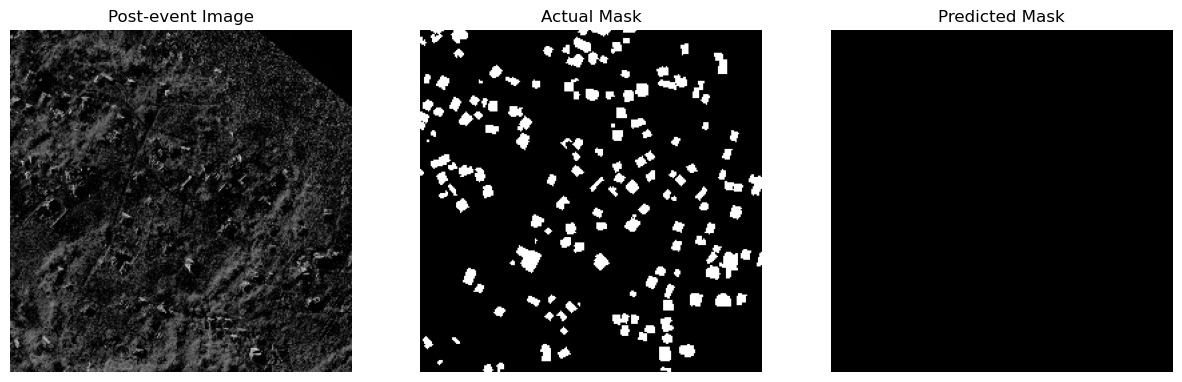

In [33]:
plt.figure(figsize=(15,5))

# Post-event image
plt.subplot(1,3,1)
plt.imshow(X_val[0][:,:,3:6])
plt.title("Post-event Image")
plt.axis("off")

# Actual mask
plt.subplot(1,3,2)
plt.imshow(y_val[0].squeeze(), cmap='gray')
plt.title("Actual Mask")
plt.axis("off")

# Predicted mask
plt.subplot(1,3,3)
plt.imshow(pred_mask.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [34]:
history = model.fit(
    X_train[:500],
    y_train[:500],

    validation_data=(X_val[:100], y_val[:100]),

    epochs=10,
    batch_size=4
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8599 - loss: 0.0051 - val_accuracy: 0.8698 - val_loss: 0.0048
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.8599 - loss: 0.0049 - val_accuracy: 0.8698 - val_loss: 0.0048
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0047
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0047
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0048
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0048
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0047
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.8599 - loss: 0.0047 - val_accu

In [35]:
sample_mask = cv2.imread(
    os.path.join(train_target_path, files[0]),
    cv2.IMREAD_GRAYSCALE
)

print("Unique values:", np.unique(sample_mask))

Unique values: [0 1]


In [36]:
def dice_coefficient(y_true, y_pred, smooth=1):

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (
        2. * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

In [37]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [38]:
def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    d_loss = dice_loss(y_true, y_pred)

    return bce + d_loss

In [40]:
model.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=['accuracy', dice_coefficient]
)

In [41]:
history = model.fit(
    X_train[:500],
    y_train[:500],

    validation_data=(X_val[:100], y_val[:100]),

    epochs=10,
    batch_size=4
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.8599 - dice_coefficient: 0.0082 - loss: 1.0018 - val_accuracy: 0.8698 - val_dice_coefficient: 0.0171 - val_loss: 0.9895
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.8599 - dice_coefficient: 0.0096 - loss: 0.9986 - val_accuracy: 0.8698 - val_dice_coefficient: 0.0365 - val_loss: 0.9707
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.8599 - dice_coefficient: 0.0086 - loss: 1.0002 - val_accuracy: 0.8698 - val_dice_coefficient: 0.0137 - val_loss: 0.9921
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.8599 - dice_coefficient: 0.0084 - loss: 0.9986 - val_accuracy: 0.8698 - val_dice_coefficient: 0.0143 - val_loss: 0.9910
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.8599 - dice_coefficient: 0.0100 - loss: 0.9969 - val_accuracy: 0.8698 - val_dice_coefficient: 0.0411 - val_loss: 0.9661
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 

In [42]:
prediction = model.predict(X_val[:1])

pred_mask = (prediction[0] > 0.3).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


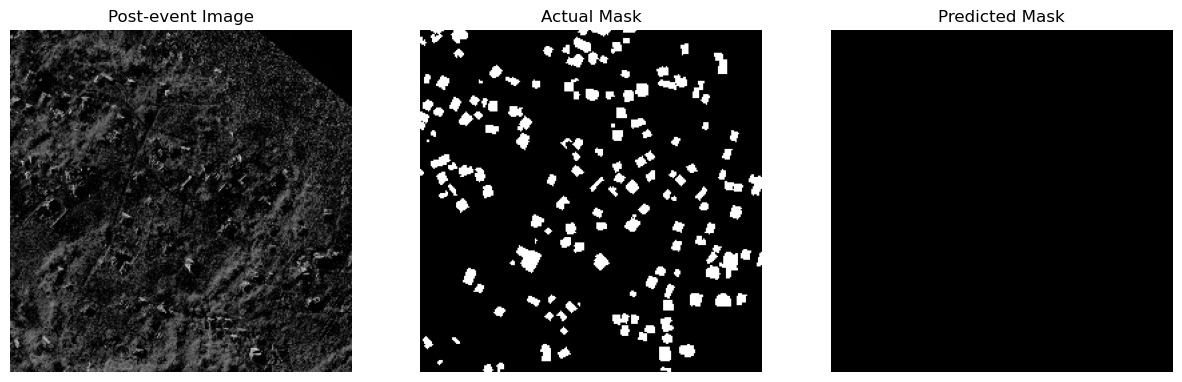

In [43]:
plt.figure(figsize=(15,5))

# Post-event image
plt.subplot(1,3,1)
plt.imshow(X_val[0][:,:,3:6])
plt.title("Post-event Image")
plt.axis("off")

# Actual mask
plt.subplot(1,3,2)
plt.imshow(y_val[0].squeeze(), cmap='gray')
plt.title("Actual Mask")
plt.axis("off")

# Predicted mask
plt.subplot(1,3,3)
plt.imshow(pred_mask.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [45]:
print("Minimum prediction:", prediction.min())
print("Maximum prediction:", prediction.max())
print("Mean prediction:", prediction.mean())

Minimum prediction: 3.108694e-27
Maximum prediction: 0.00022689124
Mean prediction: 5.6624566e-07


In [46]:
def weighted_bce(y_true, y_pred):

    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

    # higher weight for positive pixels
    weight_for_1 = 15.0
    weight_for_0 = 1.0

    bce = -(
        weight_for_1 * y_true * tf.math.log(y_pred)
        +
        weight_for_0 * (1 - y_true) * tf.math.log(1 - y_pred)
    )

    return tf.reduce_mean(bce)

In [47]:
def improved_loss(y_true, y_pred):

    wbce = weighted_bce(y_true, y_pred)

    dloss = dice_loss(y_true, y_pred)

    return wbce + dloss

In [52]:
model.compile(
    optimizer='adam',
    loss=improved_loss,
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
val_predictions = model.predict(X_val[:100])

In [28]:
history = model.fit(
    X_train[:500],
    y_train[:500],

    validation_data=(X_val[:100], y_val[:100]),

    epochs=5,
    batch_size=4
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 939ms/step - accuracy: 0.8540 - loss: 0.0379 - val_accuracy: 0.8698 - val_loss: 0.0055
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8599 - loss: 0.0053 - val_accuracy: 0.8698 - val_loss: 0.0049
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.8599 - loss: 0.0051 - val_accuracy: 0.8698 - val_loss: 0.0048
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.8599 - loss: 0.0049 - val_accuracy: 0.8698 - val_loss: 0.0047
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8599 - loss: 0.0048 - val_accuracy: 0.8698 - val_loss: 0.0049


In [29]:
model.save("change_detection_model.h5")

In [30]:
model.save("change_detection_model.keras")

In [31]:
val_predictions = model.predict(X_val[:100])

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


In [32]:
val_predictions = model.predict(X_val[:100])

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 966ms/step


In [34]:
val_pred_masks = (val_predictions > 0.3).astype(np.uint8)

In [35]:
y_true = y_val[:100].flatten()
y_pred = val_pred_masks.flatten()

In [36]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix
)

In [39]:
y_true = (y_val[:100] > 0.5).astype(np.uint8).flatten()
y_pred = val_pred_masks.flatten()

In [40]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("IoU:", iou)

C:\Users\aysha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aysha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aysha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.0
Recall: 0.0
F1 Score: 0.0
IoU: 0.0


C:\Users\aysha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
